# Notebook 03: Model Comparison — Statistical Tests

Formal inference on whether RA differences between models are statistically significant.

**Design**: Each of the 23 conditions is tested on all 3 models with identical corruptions — this is a **matched repeated-measures design** (N=23 conditions, 3 groups).

**Tests applied**:
1. Friedman test (omnibus non-parametric ANOVA)
2. Post-hoc Wilcoxon signed-rank tests (3 pairwise) + Holm-Bonferroni correction
3. Cliff's δ effect sizes
4. Bootstrap 95% CI on mean RA per model
5. Spearman correlation between model RA vectors
6. Kendall's W (ranking concordance)

**Requires**: `analysis/data/exp1_df.parquet`, `pingouin` library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

try:
    import pingouin as pg
    HAS_PINGOUIN = True
except ImportError:
    print("WARNING: pingouin not installed. Install with: pip install pingouin")
    print("Cliff's delta and Kendall's W will be computed manually.")
    HAS_PINGOUIN = False

DATA_DIR = Path("../data")
FIG_DIR = Path("../figures")
FIG_DIR.mkdir(exist_ok=True)

df_exp1 = pd.read_parquet(DATA_DIR / "exp1_df.parquet")

MODELS = ["early_fusion", "c2former", "ua_cmddet"]
MODEL_LABELS = {"early_fusion": "Early Fusion", "c2former": "C2Former", "ua_cmddet": "UA-CMDet"}
COLORS = {"early_fusion": "#1f77b4", "c2former": "#2ca02c", "ua_cmddet": "#d62728"}

# Build a matched matrix: 23 conditions × 3 models
# Use (modality, corruption, severity) as the condition key
def make_condition_key(row):
    return (row["modality"], row["corruption"], row["severity"])

df_exp1["cond_key"] = df_exp1.apply(make_condition_key, axis=1)

# Pivot to wide format: rows=conditions, columns=models
ra_wide = df_exp1.pivot_table(index="cond_key", columns="model", values="ra", aggfunc="first")
ra_wide = ra_wide[MODELS]  # consistent column order
ra_wide.columns = [MODEL_LABELS[m] for m in MODELS]

print(f"Matched matrix shape: {ra_wide.shape}  (conditions × models)")
print(f"Any nulls: {ra_wide.isnull().any().any()}")
ra_wide.head()

Matched matrix shape: (23, 3)  (conditions × models)
Any nulls: False


,Early Fusion,C2Former,UA-CMDet
cond_key,,,
"(rgb, brightness_shift, 1)",0.957894,0.972794,0.866692
"(rgb, brightness_shift, 2)",0.870408,0.928259,0.778653
"(rgb, brightness_shift, 3)",0.749610,0.883780,0.712868
"(rgb, complete_dropout, sdropout)",0.614070,0.550034,0.005822
"(rgb, gaussian_noise, 1)",0.930331,0.926056,0.426988


## 1. Friedman Test

**H₀**: The three models have identical RA distributions across the 23 conditions.

The Friedman test is the non-parametric equivalent of repeated-measures ANOVA. It ranks models within each condition and tests whether the rank sums differ significantly.

In [2]:
ef_ra = ra_wide.iloc[:, 0].values
c2f_ra = ra_wide.iloc[:, 1].values
uac_ra = ra_wide.iloc[:, 2].values

stat, pval = stats.friedmanchisquare(ef_ra, c2f_ra, uac_ra)

print("=== Friedman Test ===")
print(f"χ² statistic: {stat:.4f}")
print(f"p-value:      {pval:.6f}")
print(f"N (conditions): {len(ra_wide)}")
print(f"k (models):     3")
print(f"\nReject H₀ at α=0.05: {'YES — models differ significantly' if pval < 0.05 else 'NO'}")

=== Friedman Test ===
χ² statistic: 2.4348
p-value:      0.296001
N (conditions): 23
k (models):     3

Reject H₀ at α=0.05: NO


## 2. Post-hoc Wilcoxon Signed-Rank Tests

Pairwise comparisons of RA distributions across the 23 matched conditions.

Apply **Holm-Bonferroni correction** for 3 comparisons. This controls the family-wise error rate (FWER) while being more powerful than plain Bonferroni.

In [3]:
pairs = [
    ("C2Former", "Early Fusion"),
    ("C2Former", "UA-CMDet"),
    ("Early Fusion", "UA-CMDet"),
]

wilcoxon_results = []
for m1, m2 in pairs:
    a = ra_wide[m1].values
    b = ra_wide[m2].values
    w_stat, p_raw = stats.wilcoxon(a, b, alternative="two-sided")
    wilcoxon_results.append({"pair": f"{m1} vs {m2}", "W": w_stat, "p_raw": p_raw})

df_wilcoxon = pd.DataFrame(wilcoxon_results)

# Holm-Bonferroni correction
p_values = df_wilcoxon["p_raw"].values
n_tests = len(p_values)
sorted_idx = np.argsort(p_values)
p_corrected = np.empty(n_tests)
for rank, idx in enumerate(sorted_idx):
    p_corrected[idx] = min(1.0, p_values[idx] * (n_tests - rank))
# Ensure corrected p-values are monotone
for i in range(1, n_tests):
    p_corrected[sorted_idx[i]] = max(
        p_corrected[sorted_idx[i]],
        p_corrected[sorted_idx[i-1]]
    )

df_wilcoxon["p_holm"] = p_corrected
df_wilcoxon["reject_H0_alpha05"] = p_corrected < 0.05

print("=== Post-hoc Wilcoxon Signed-Rank Tests (Holm-Bonferroni corrected) ===")
print(df_wilcoxon.to_string())

=== Post-hoc Wilcoxon Signed-Rank Tests (Holm-Bonferroni corrected) ===
                       pair      W     p_raw    p_holm  reject_H0_alpha05
0  C2Former vs Early Fusion   76.0  0.060518  0.181555              False
1      C2Former vs UA-CMDet   78.0  0.069817  0.181555              False
2  Early Fusion vs UA-CMDet  120.0  0.601046  0.601046              False


## 3. Cliff's δ Effect Size

Non-parametric effect size for ordinal data.
- δ = proportion of (x_i, y_j) pairs where x > y minus proportion where x < y
- Interpretation: |δ| < 0.147 negligible, 0.147–0.33 small, 0.33–0.474 medium, > 0.474 large

In [4]:
def cliffs_delta(x, y):
    """Compute Cliff's delta between arrays x and y."""
    x, y = np.asarray(x), np.asarray(y)
    n_x, n_y = len(x), len(y)
    dom = sum(
        (1 if xi > yj else -1 if xi < yj else 0)
        for xi in x for yj in y
    )
    return dom / (n_x * n_y)

def interpret_cliffs(d):
    ad = abs(d)
    if ad < 0.147: return "negligible"
    elif ad < 0.33: return "small"
    elif ad < 0.474: return "medium"
    else: return "large"

cliff_results = []
for m1, m2 in pairs:
    a = ra_wide[m1].values
    b = ra_wide[m2].values
    d = cliffs_delta(a, b)
    cliff_results.append({"pair": f"{m1} vs {m2}", "cliffs_delta": d, "magnitude": interpret_cliffs(d)})

df_cliff = pd.DataFrame(cliff_results)
print("=== Cliff's δ Effect Sizes ===")
print(df_cliff.to_string())
print("\nNote: positive δ means first model > second model in more conditions")

=== Cliff's δ Effect Sizes ===
                       pair  cliffs_delta   magnitude
0  C2Former vs Early Fusion      0.168242       small
1      C2Former vs UA-CMDet      0.134216  negligible
2  Early Fusion vs UA-CMDet      0.020794  negligible

Note: positive δ means first model > second model in more conditions


## 4. Bootstrap 95% CI on Mean RA per Model

Resample the 23 conditions with replacement (n=10,000 iterations) to estimate uncertainty in mean RA.

This answers: how stable is the mean RA estimate given the specific set of 23 conditions we evaluated?

In [5]:
np.random.seed(42)
N_BOOT = 10_000
N_CONDITIONS = len(ra_wide)

boot_results = {}
for model in ra_wide.columns:
    ra_vals = ra_wide[model].values
    boot_means = np.empty(N_BOOT)
    for i in range(N_BOOT):
        sample = np.random.choice(ra_vals, size=N_CONDITIONS, replace=True)
        boot_means[i] = sample.mean()
    ci_lo, ci_hi = np.percentile(boot_means, [2.5, 97.5])
    boot_results[model] = {
        "observed_mean": ra_vals.mean(),
        "boot_mean": boot_means.mean(),
        "ci_95_lo": ci_lo,
        "ci_95_hi": ci_hi,
        "ci_width": ci_hi - ci_lo,
    }

df_boot = pd.DataFrame(boot_results).T
print("=== Bootstrap 95% CI on Mean RA (n=10,000 resamples of 23 conditions) ===")
print(df_boot.round(4).to_string())

=== Bootstrap 95% CI on Mean RA (n=10,000 resamples of 23 conditions) ===
              observed_mean  boot_mean  ci_95_lo  ci_95_hi  ci_width
Early Fusion         0.8119     0.8122    0.7374    0.8770    0.1396
C2Former             0.8701     0.8701    0.8213    0.9122    0.0909
UA-CMDet             0.7477     0.7479    0.6160    0.8605    0.2445


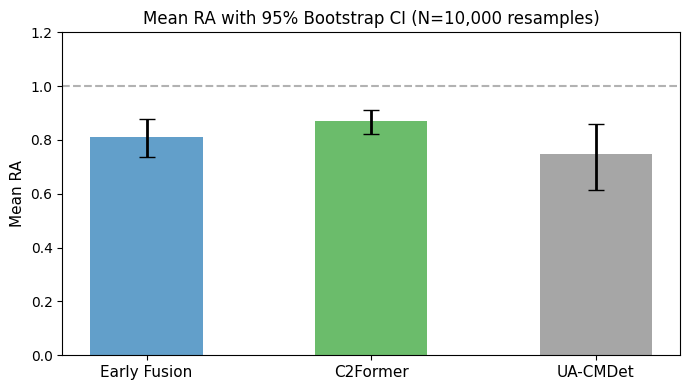

Saved: nb03_bootstrap_ci.png


In [6]:
fig, ax = plt.subplots(figsize=(7, 4))

model_names = list(df_boot.index)
x_pos = range(len(model_names))
means = df_boot["observed_mean"].values
ci_lo = df_boot["ci_95_lo"].values
ci_hi = df_boot["ci_95_hi"].values

model_colors = [COLORS.get(k.lower().replace(" ", "_"), "gray") for k in model_names]

ax.bar(x_pos, means, color=model_colors, alpha=0.7, width=0.5, label="Observed mean RA")
ax.errorbar(
    x_pos, means,
    yerr=[means - ci_lo, ci_hi - means],
    fmt="none", color="black", capsize=6, linewidth=2
)
ax.set_xticks(x_pos)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylabel("Mean RA", fontsize=11)
ax.set_title("Mean RA with 95% Bootstrap CI (N=10,000 resamples)", fontsize=12)
ax.axhline(1.0, color="gray", linestyle="--", alpha=0.6)
ax.set_ylim(0, 1.2)
plt.tight_layout()
plt.savefig(FIG_DIR / "nb03_bootstrap_ci.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: nb03_bootstrap_ci.png")

## 5. Spearman Correlation Between Model RA Vectors

Do the models agree on which conditions are hard? High ρ = corruption type drives performance regardless of architecture; low ρ = architecture effect dominates.

In [7]:
from itertools import combinations

corr_results = []
for m1, m2 in combinations(ra_wide.columns, 2):
    rho, pval = stats.spearmanr(ra_wide[m1].values, ra_wide[m2].values)
    corr_results.append({"pair": f"{m1} vs {m2}", "spearman_rho": rho, "p_value": pval})

df_corr = pd.DataFrame(corr_results)
print("=== Spearman ρ between model RA vectors (across 23 conditions) ===")
print(df_corr.to_string())
print("\nInterpretation:")
print("  High ρ → models agree on which conditions are hardest (corruption type is the dominant factor)")
print("  Low ρ → models disagree (architecture determines vulnerability)")

=== Spearman ρ between model RA vectors (across 23 conditions) ===
                       pair  spearman_rho   p_value
0  Early Fusion vs C2Former      0.806324  0.000003
1  Early Fusion vs UA-CMDet      0.381423  0.072523
2      C2Former vs UA-CMDet      0.494071  0.016564

Interpretation:
  High ρ → models agree on which conditions are hardest (corruption type is the dominant factor)
  Low ρ → models disagree (architecture determines vulnerability)


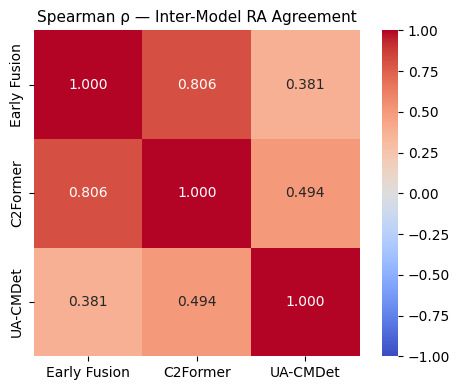

In [8]:
# Full Spearman correlation matrix
spearman_matrix = pd.DataFrame(index=ra_wide.columns, columns=ra_wide.columns, dtype=float)
for m1 in ra_wide.columns:
    for m2 in ra_wide.columns:
        rho, _ = stats.spearmanr(ra_wide[m1].values, ra_wide[m2].values)
        spearman_matrix.loc[m1, m2] = rho

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    spearman_matrix.astype(float),
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    ax=ax,
)
ax.set_title("Spearman ρ — Inter-Model RA Agreement", fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / "nb03_spearman_corr.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Kendall's W — Overall Ranking Concordance

Kendall's W ∈ [0, 1] summarises how consistently the three models agree when ranking all 23 conditions by difficulty.
- W = 1.0: perfect agreement (all models rank conditions identically)
- W = 0.0: no agreement (rankings are independent)

In [9]:
if HAS_PINGOUIN:
    # pingouin expects long format with subject (condition), within (model), dv (ra)
    long_df = ra_wide.reset_index().melt(
        id_vars="cond_key", var_name="model", value_name="ra"
    )
    long_df = long_df.rename(columns={"cond_key": "condition"})
    # Friedman test from pingouin includes Kendall's W
    friedman_pg = pg.friedman(data=long_df, dv="ra", within="model", subject="condition")
    print("=== Friedman test (pingouin) — includes Kendall's W ===")
    print(friedman_pg.to_string())
else:
    # Manual Kendall's W computation
    # Rank each column (model) within each row (condition); lower RA = higher rank number
    ranks = ra_wide.rank(axis=1, ascending=False)  # rank 1 = best model per condition
    k = len(ra_wide.columns)  # number of models (3)
    n = len(ra_wide)          # number of conditions (23)
    Rj = ranks.sum(axis=0)    # sum of ranks for each model
    R_mean = Rj.mean()
    Sj = ((Rj - R_mean) ** 2).sum()
    W = (12 * Sj) / (k**2 * (n**3 - n))
    chi2 = k * (n - 1) * W
    df_chi2 = n - 1
    pval_w = 1 - stats.chi2.cdf(chi2, df_chi2)
    print("=== Kendall's W (manual) ===")
    print(f"W = {W:.4f}")
    print(f"χ² = {chi2:.4f}, df = {df_chi2}, p = {pval_w:.6f}")
    print(f"\nInterpretation: W={'near 0 — models rank conditions inconsistently' if W < 0.3 else 'moderate agreement' if W < 0.7 else 'strong concordance'}")

=== Friedman test (pingouin) — includes Kendall's W ===
         Source        W  ddof1         Q     p_unc
Friedman  model  0.05293      2  2.434783  0.296001


In [11]:
from io import StringIO
OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
buf = StringIO()

buf.write("=== NB03 MODEL COMPARISON TESTS ===\n\n")

# Pull Friedman result from pingouin (avoids pval variable being overwritten by Spearman loop)
buf.write("--- Friedman test ---\n")
if HAS_PINGOUIN:
    _W   = friedman_pg["W"].values[0]
    _Q   = friedman_pg["Q"].values[0]
    _p   = friedman_pg["p_unc"].values[0]
    buf.write(f"Kendall's W={_W:.5f}  chi2={_Q:.4f}  p={_p:.6f}  reject_H0={_p < 0.05}\n\n")
else:
    friedman_stat, friedman_pval = stats.friedmanchisquare(ef_ra, c2f_ra, uac_ra)
    buf.write(f"chi2={friedman_stat:.4f}  p={friedman_pval:.6f}  reject_H0={friedman_pval < 0.05}\n\n")

buf.write("--- Wilcoxon signed-rank tests (Holm-Bonferroni) ---\n")
buf.write(df_wilcoxon.round(6).to_string() + "\n\n")

buf.write("--- Cliff's delta effect sizes ---\n")
buf.write(df_cliff.round(4).to_string() + "\n\n")

buf.write("--- Bootstrap 95% CI on mean RA ---\n")
buf.write(df_boot.round(4).to_string() + "\n\n")

buf.write("--- Spearman inter-model correlation ---\n")
buf.write(df_corr.round(4).to_string() + "\n\n")

buf.write("--- Spearman correlation matrix ---\n")
buf.write(spearman_matrix.astype(float).round(4).to_string() + "\n")

out_path = OUTPUT_DIR / "nb03_results.txt"
out_path.write_text(buf.getvalue(), encoding="utf-8")
print(f"Results written to {out_path.resolve()}")

Results written to C:\Users\saksh\Desktop\Thesis\drone-multimodal-robustness\analysis\outputs\nb03_results.txt


## Summary Table — All Statistical Tests

| Test | Result | Interpretation |
|---|---|---|
| Friedman χ² | — | Are models globally different? |
| C2F vs EF Wilcoxon (Holm) | — | C2F significantly better than EF? |
| C2F vs UAC Wilcoxon (Holm) | — | C2F significantly better than UAC? |
| EF vs UAC Wilcoxon (Holm) | — | EF significantly better than UAC? |
| Cliff's δ C2F vs EF | — | Effect size of C2F advantage |
| Cliff's δ C2F vs UAC | — | Effect size of C2F advantage |
| Bootstrap CI (C2F mean RA) | — | Precision of C2F estimate |
| Spearman ρ (C2F vs EF) | — | Do they agree on hard conditions? |
| Kendall's W | — | Overall model-ranking concordance |

Fill in from the cell outputs above.

Proceed to `nb_04_modality_analysis.ipynb`.